In [1]:
! pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_parquet("hf://datasets/ganga4364/garchen_rinpoche_benchmark_result/data/train-00000-of-00001.parquet")


In [3]:
import pandas as pd 

#df = pd.read_csv("GR_benchmark.csv")

In [4]:
df.head(2)

,file_name,url,inference_transcript,audio_duration,original_id,strata,age_group,duration_category,content_type,path,inference_checkpoint-10000,inference_checkpoint-19000,inference_checkpoint-5000,uni,base_cer,cer_5000,cer_10000,cer_19000
0,STT_GR_0001_0010_93600_to_106200,https://d38pmlk0v88drf.cloudfront.net/wav16k/S...,ཁོང་ཨེ་ནས་དགེ་སྡུན་ཁྲད་ི་ལྔ་རྡག་རེད།་བུ་གླིང་ྡ...,12.600,STT_GR_0001,70-80__short__Teaching,70-80,short,Teaching,./downloads/STT_GR_0001_0010_93600_to_106200.wav,ཁོང་ དེ་ནས་དགེ་འདུན་ཁྲིཡི་རྔ་ཟདག་རེད། བུ་གླིང...,ཁོང་། དེ་ནས་དགེ་འདུ་ཁྲིཡི་རྔ་བདག་རེད། བུ་གླིང...,ཁོང་། དེ་ནས་དགེ་འདུས་ཁྲིའི། ལང་དག་རེད། བུ་གླིང...,ཁོང་དེ་ནས་དགེ་འདུན་ཁྲི་ལ་སྔོན་ཟླ་རེ་བོད་གླེང་ད...,0.229050,0.290503,0.279330,0.284916
1,STT_GR_0033_0105_224320_to_225856,https://d38pmlk0v88drf.cloudfront.net/wav16k/S...,ཨ་ཕ་པ་རེ་འོ་ར་དེའ་ཐག་ནས་,1.536,STT_GR_0033,70-80__short__Teaching,70-80,short,Teaching,./downloads/STT_GR_0033_0105_224320_to_225856.wav,ཨ། ཕན་པ་རེ་འོད་ན་དེ་མཚས་ན་,ཨ། ཕན་པ་རེ་འོད་ན་དེ་ཐེང་ལུ,ཨེ།་ཕན་པ་རེད་འོ་ནི་དེ་ལྟེ་ནུ།,ཕ་གི་ཕར་རང་རེ་རྫས་ཚར་ལེ།,0.708333,0.791667,0.833333,0.833333


In [5]:
df['char_len'] = df['uni'].str.len()

In [6]:
df['char_len'].describe()

count    893.000000
mean      73.417693
std       85.058798
min        3.000000
25%       23.000000
50%       40.000000
75%       86.000000
max      470.000000
Name: char_len, dtype: float64

<Axes: >

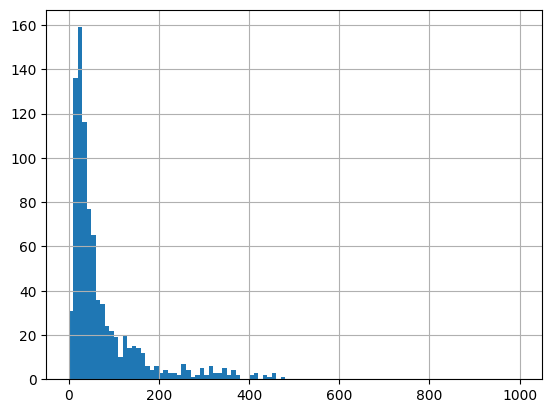

In [7]:
df['char_len'].hist(bins=100, range=(0, 1000))

In [8]:
strata_groups = df.groupby('strata')['original_id'].unique()

print('\nOriginal IDs for each strata:')
for strata, ids in strata_groups.items():
    print(f'\n{strata}:')
    print(', '.join(ids))


Original IDs for each strata:

70-80__long__Prayer:
STT_GR_0022, STT_GR_0028

70-80__long__Q&A:
STT_GR_0019, STT_GR_0024, STT_GR_0011

70-80__long__Teaching:
STT_GR_0004, STT_GR_0016, STT_GR_0010, STT_GR_0021, STT_GR_0002, STT_GR_0012, STT_GR_0003, STT_GR_0029, STT_GR_0023, STT_GR_0014

70-80__medium__Prayer:
STT_GR_0030, STT_GR_0026

70-80__medium__Q&A:
STT_GR_0027

70-80__medium__Teaching:
STT_GR_0020, STT_GR_0025, STT_GR_0031, STT_GR_0013, STT_GR_0017, STT_GR_0008, STT_GR_0015, STT_GR_0005, STT_GR_0007, STT_GR_0006, STT_GR_0009

70-80__short__Teaching:
STT_GR_0001, STT_GR_0033, STT_GR_0032, STT_GR_0018

80-90__long__Practice:
STT_GR_0037, STT_GR_0034, STT_GR_0038, STT_GR_0035, STT_GR_0036


In [9]:
grouped = df.groupby('original_id')['char_len'].agg(['sum', 'mean', 'count'])
print('\nCharacter length statistics grouped by original_id:')
print(grouped)


Character length statistics grouped by original_id:
              sum        mean  count
original_id                         
STT_GR_0001  1697  121.214286     14
STT_GR_0002   389   32.416667     12
STT_GR_0003   712   54.769231     13
STT_GR_0004  1256   73.882353     17
STT_GR_0005   880  125.714286      7
STT_GR_0006   720   65.454545     11
STT_GR_0007  1228  102.333333     12
STT_GR_0008   459   30.600000     15
STT_GR_0009   308   61.600000      5
STT_GR_0010   967   74.384615     13
STT_GR_0011  2910  116.400000     25
STT_GR_0012   602   31.684211     19
STT_GR_0013   312   62.400000      5
STT_GR_0014   512  102.400000      5
STT_GR_0015  1418   88.625000     16
STT_GR_0016   536   89.333333      6
STT_GR_0017  1448   76.210526     19
STT_GR_0018  1265   57.500000     22
STT_GR_0019  2830   50.535714     56
STT_GR_0020   917  131.000000      7
STT_GR_0021   841   60.071429     14
STT_GR_0022  6566   84.179487     78
STT_GR_0023   531   66.375000      8
STT_GR_0024  2911  107

In [10]:
df_0022 = df[df['original_id'] == 'STT_GR_0022']

In [11]:
df_0022.head(2)

,file_name,url,inference_transcript,audio_duration,original_id,strata,age_group,duration_category,content_type,path,inference_checkpoint-10000,inference_checkpoint-19000,inference_checkpoint-5000,uni,base_cer,cer_5000,cer_10000,cer_19000,char_len
472,STT_GR_0022_0189_1500500_to_1504500,https://d38pmlk0v88drf.cloudfront.net/wav16k/S...,ཨ། ཚག་པུ་དེ་ལ་ངུས་བཙོང་ཡོད་མ་རེད། ནམ་མཁའ་ལྟ་བ་...,4.0,STT_GR_0022,70-80__long__Prayer,70-80,long,Prayer,./downloads/STT_GR_0022_0189_1500500_to_150450...,ཨ། སེམས་ཀྱི་གནས་ལུགས་ངོས་བཟུང་ཡོད་མ་རེད། ནམ་མཁ...,ཨ། སེམས་ཀྱི་གནས་ལུགས་ངོས་བཟུང་ཡོད་མ་རེད། ནམ་མཁ...,ཨ་ཚེམས་པན་དེ་ལ་ངོས་བཟུང་ཡོད་མ་རེད། ནམ་མཁའ་ལྟ་བུ།,ཨོང་སེམས་ཀྱིས་དེ་ངེས་བཟུང་ཡོད་མ་རེད། ནམ་མཁའ་ལྟ...,0.379310,0.310345,0.258621,0.258621,58
473,STT_GR_0022_0158_1283900_to_1295800,https://d38pmlk0v88drf.cloudfront.net/wav16k/S...,དོན་དབ་དུ་ད་ལྟ་འཁོར་ཐབ་རྣམ་པར་དག་པ་དེ་ལྟ་བུ་ ཡ...,11.9,STT_GR_0022,70-80__long__Prayer,70-80,long,Prayer,./downloads/STT_GR_0022_0158_1283900_to_129580...,དོན་དམ་དུ་ད་ལྟ་འཁོར་གསུམ་རྣམ་པར་དག་པ་དེ་ལྟ་བུ་...,དོན་དམ་དུ་ད་ལྟ་འཁོར་གསུམ་རྣམ་པར་དག་པ་དེ་ལྟ་བུ་...,དོན་དམ་དེ་ད་ལྟ་འཁོར་གསུམ་རྣམ་པར་ྟག་པ་དེ་ལྟ་བུ་...,དོན་དམ་ད་ལྟ་འཁོར་ཚོགས་རྣམ་པར་དག་པ་དེ་ལྟ་བུ་ཡིན...,0.181818,0.205742,0.162679,0.162679,211


<Axes: >

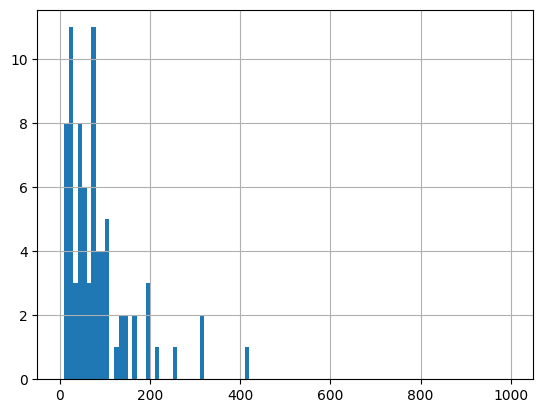

In [12]:
df_0022['char_len'].hist(bins=100, range=(0, 1000))

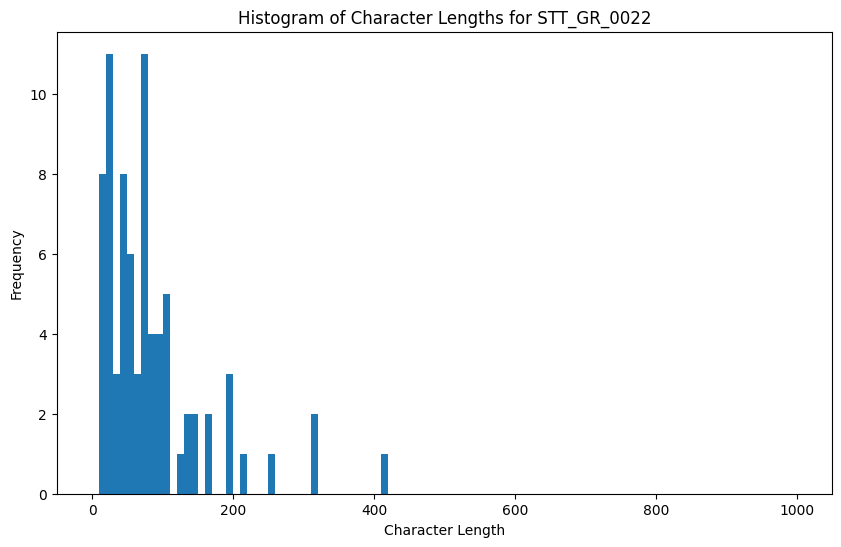


Bin range: (50.0, 60.0]
Files in this bin:
File: STT_GR_0022_0189_1500500_to_1504500, Char Length: 58
File: STT_GR_0022_0172_1421600_to_1425700, Char Length: 52
File: STT_GR_0022_0078_678200_to_680700, Char Length: 57
File: STT_GR_0022_0215_1625312_to_1627584, Char Length: 58
File: STT_GR_0022_0328_2132252_to_2134652, Char Length: 55
File: STT_GR_0022_0192_1514900_to_1519800, Char Length: 57

Bin range: (210.0, 220.0]
Files in this bin:
File: STT_GR_0022_0158_1283900_to_1295800, Char Length: 211

Bin range: (70.0, 80.0]
Files in this bin:
File: STT_GR_0022_0034_293600_to_300100, Char Length: 78
File: STT_GR_0022_0190_1504900_to_1509500, Char Length: 74
File: STT_GR_0022_0024_195500_to_200600, Char Length: 74
File: STT_GR_0022_0074_637800_to_642400, Char Length: 71
File: STT_GR_0022_0004_34700_to_38500, Char Length: 74
File: STT_GR_0022_0119_1138204_to_1141468, Char Length: 77
File: STT_GR_0022_0089_778400_to_783700, Char Length: 73
File: STT_GR_0022_0287_1948800_to_1956500, Char Lengt

/tmp/ipykernel_59776/4204568450.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0022['char_len_bin'] = pd.cut(df_0022['char_len'], bins=bins)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create histogram
plt.figure(figsize=(10, 6))
hist, bins = np.histogram(df_0022['char_len'], bins=100, range=(0, 1000))
plt.hist(df_0022['char_len'], bins=100, range=(0, 1000))
plt.title('Histogram of Character Lengths for STT_GR_0022')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.show()

# Create bin labels and assign rows to bins
df_0022['char_len_bin'] = pd.cut(df_0022['char_len'], bins=bins)

# Group files by their bins
for bin_range in df_0022['char_len_bin'].unique():
    bin_files = df_0022[df_0022['char_len_bin'] == bin_range]
    if len(bin_files) > 0:  # Only show bins that have files
        print(f"\nBin range: {bin_range}")
        print("Files in this bin:")
        for _, row in bin_files.iterrows():
            print(f"File: {row['file_name']}, Char Length: {row['char_len']}")

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Get unique original_ids
original_ids = df['original_id'].unique()
summary_stats = []

for original_id in original_ids:
    # Create directory for this original_id
    report_dir = Path(f'character_length_reports/{original_id}')
    report_dir.mkdir(parents=True, exist_ok=True)
    
    # Filter for this original_id
    df_current = df[df['original_id'] == original_id]
    
    # Create histogram
    plt.figure(figsize=(10, 6))
    hist, bins = np.histogram(df_current['char_len'], bins=100, range=(0, 1000))
    plt.hist(df_current['char_len'], bins=100, range=(0, 1000))
    plt.title(f'Character Length Distribution for {original_id}')
    plt.xlabel('Character Length')
    plt.ylabel('Frequency')
    plt.savefig(report_dir / 'histogram.png')
    plt.close()
    
    # Create bin labels and assign rows to bins
    df_current = df_current.copy()
    df_current['char_len_bin'] = pd.cut(df_current['char_len'], bins=bins)
    
    # Calculate statistics
    total_segments = len(df_current)
    total_duration = df_current['audio_duration'].sum()
    total_chars = df_current['char_len'].sum()
    avg_chars_per_segment = df_current['char_len'].mean()
    
    # Add to summary stats
    summary_stats.append({
        'original_id': original_id,
        'total_segments': total_segments,
        'total_duration': total_duration,
        'total_chars': total_chars,
        'avg_chars_per_segment': avg_chars_per_segment
    })
    
    # Create markdown report
    with open(report_dir / 'report.md', 'w') as f:
        # Write header
        f.write(f"# Analysis Report for {original_id}\n\n")
        
        # Write summary statistics
        f.write("## Summary Statistics\n\n")
        f.write("| Metric | Value |\n")
        f.write("|--------|-------|\n")
        f.write(f"| Total Segments | {total_segments} |\n")
        f.write(f"| Total Duration | {total_duration:.2f} seconds |\n")
        f.write(f"| Total Characters | {total_chars} |\n")
        f.write(f"| Average Characters/Segment | {avg_chars_per_segment:.2f} |\n\n")
        
        # Add histogram image
        f.write("## Character Length Distribution\n\n")
        f.write(f"![Histogram](histogram.png)\n\n")
        
        # Write bin statistics
        f.write("## Detailed Statistics by Character Length Bins\n\n")
        
        bin_stats = df_current.groupby('char_len_bin').agg({
            'file_name': 'count',
            'char_len': ['mean', 'sum'],
            'audio_duration': ['mean', 'sum']
        }).round(2)
        
        for bin_range, stats in bin_stats.iterrows():
            if stats[('file_name', 'count')] > 0:
                f.write(f"### Bin: {bin_range}\n\n")
                f.write("| Metric | Value |\n")
                f.write("|--------|-------|\n")
                f.write(f"| Number of Segments | {stats[('file_name', 'count')]} |\n")
                f.write(f"| Average Character Length | {stats[('char_len', 'mean')]} |\n")
                f.write(f"| Total Characters | {stats[('char_len', 'sum')]} |\n")
                f.write(f"| Average Duration | {stats[('audio_duration', 'mean')]} seconds |\n")
                f.write(f"| Total Duration | {stats[('audio_duration', 'sum')]} seconds |\n\n")
                
                # List files in this bin
                f.write("#### Files in this bin:\n\n")
                f.write("| File Name | Character Length | Duration (s) |\n")
                f.write("|-----------|-----------------|---------------|\n")  # Removed extra |
                                
                files_in_bin = df_current[df_current['char_len_bin'] == bin_range]
                for _, row in files_in_bin.iterrows():
                    f.write(f"| {row['file_name']} | {row['char_len']} | {row['audio_duration']:.2f} |\n")
                f.write("\n")
    
    # Save the raw data for this original_id
    df_current.to_csv(report_dir / 'data.csv', index=False)

# Create summary report
summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('character_length_reports/summary_all_originals.csv', index=False)

# Create summary markdown
# Create summary markdown
with open('character_length_reports/summary.md', 'w') as f:
    f.write("# Summary of All Original IDs\n\n")
    f.write("| Original ID | Total Segments | Total Duration (s) | Total Characters | Avg Chars/Segment |\n")
    f.write("|-------------|----------------|-------------------|------------------|-------------------|\n")  # Fixed spacing
    for _, row in summary_df.iterrows():
        f.write(f"| {row['original_id']} | {row['total_segments']} | {row['total_duration']:.2f} | "
                f"{row['total_chars']} | {row['avg_chars_per_segment']:.2f} |\n")

print("Reports have been generated in the 'character_length_reports' directory")

/tmp/ipykernel_59776/2043576344.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_current.groupby('char_len_bin').agg({
/tmp/ipykernel_59776/2043576344.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_current.groupby('char_len_bin').agg({
/tmp/ipykernel_59776/2043576344.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_current.groupby('char_len_bin').agg({
/tmp/ipyke

Reports have been generated in the 'character_length_reports' directory


/tmp/ipykernel_59776/2043576344.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_current.groupby('char_len_bin').agg({


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Create the main reports directory if it doesn't exist
Path('character_length_strata_reports').mkdir(exist_ok=True)

# Get strata groups
strata_groups = df.groupby('strata')['original_id'].unique()

# Create strata summary report
with open('character_length_strata_reports/strata_summary.md', 'w') as f:
    f.write("# Strata Analysis Summary\n\n")
    
    # Overall statistics
    f.write("## Overall Statistics\n\n")
    f.write(f"Total number of unique strata: {len(strata_groups)}\n")
    f.write(f"Total number of original IDs: {len(df['original_id'].unique())}\n\n")
    
    # Detailed strata breakdown
    f.write("## Strata Breakdown\n\n")
    
    for strata, ids in strata_groups.items():
        # Get all segments for this strata
        strata_df = df[df['strata'] == strata]
        
        # Calculate statistics for this strata
        total_segments = len(strata_df)
        total_duration = strata_df['audio_duration'].sum()
        total_chars = strata_df['char_len'].sum()
        avg_chars_per_segment = strata_df['char_len'].mean()
        
        f.write(f"### {strata}\n\n")
        f.write("#### Statistics\n")
        f.write("| Metric | Value |\n")
        f.write("|--------|-------|\n")
        f.write(f"| Number of Original IDs | {len(ids)} |\n")
        f.write(f"| Total Segments | {total_segments} |\n")
        f.write(f"| Total Duration | {total_duration:.2f} seconds |\n")
        f.write(f"| Total Characters | {total_chars} |\n")
        f.write(f"| Average Characters/Segment | {avg_chars_per_segment:.2f} |\n\n")
        
        f.write("#### Original IDs in this strata\n")
        f.write("```\n")
        f.write(", ".join(ids))
        f.write("\n```\n\n")
        
        # Create a histogram for this strata
        plt.figure(figsize=(10, 6))
        strata_df['char_len'].hist(bins=50, range=(0, 1000))
        plt.title(f'Character Length Distribution for {strata}')
        plt.xlabel('Character Length')
        plt.ylabel('Frequency')
        plt.savefig(f'character_length_strata_reports/strata_{strata.replace("/", "_")}_histogram.png')
        plt.close()
        
        f.write(f"#### Character Length Distribution\n")
        f.write(f"![Histogram for {strata}](strata_{strata.replace('/', '_')}_histogram.png)\n\n")
        f.write("---\n\n")

print("Strata summary report has been generated in 'character_length_strata_reports/strata_summary.md'")

Strata summary report has been generated in 'character_length_strata_reports/strata_summary.md'


In [16]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('/home/gangagyatso/Downloads/stt_transcription_speed_test/character_length_reports/STT_GR_0001/data.csv')

# Group by char_len_bin and count occurrences
bin_counts = df.groupby('char_len_bin').size()

# Find bins with 3 or more files
qualifying_bins = bin_counts[bin_counts >= 3]

print("Bins with 3 or more files:")
print("=========================")
for bin_name, count in qualifying_bins.items():
    print(f"\nCharacter length bin: {bin_name}")
    print(f"Number of files: {count}")
    print("\nFiles in this bin:")
    files_in_bin = df[df['char_len_bin'] == bin_name]
    for _, row in files_in_bin.iterrows():
        print(f"- {row['file_name']}")
        print(f"  Characters: {row['char_len']}")
        print(f"  Duration: {row['audio_duration']:.2f}s")
        if 'base_cer' in row:
            print(f"  Base CER: {row['base_cer']:.3f}")
        print("---")

Bins with 3 or more files:

Character length bin: (40.0, 50.0]
Number of files: 3

Files in this bin:
- STT_GR_0001_0019_192100_to_196200
  Characters: 44
  Duration: 4.10s
  Base CER: 0.409
---
- STT_GR_0001_0012_111300_to_114300
  Characters: 47
  Duration: 3.00s
  Base CER: 0.089
---
- STT_GR_0001_0011_106500_to_110900
  Characters: 48
  Duration: 4.40s
  Base CER: 0.261
---


In [17]:
import pandas as pd
from pathlib import Path

# Get base directory
base_dir = Path('/home/gangagyatso/Downloads/stt_transcription_speed_test/character_length_reports')

# Find all data.csv files
data_files = list(base_dir.glob('*/data.csv'))

# Dictionary to store results
results = {}

for data_file in data_files:
    original_id = data_file.parent.name
    df = pd.read_csv(data_file)
    
    # Group by char_len_bin and count occurrences
    bin_counts = df.groupby('char_len_bin').size()
    
    # Find bins with 3 or more files
    qualifying_bins = bin_counts[bin_counts >= 3]
    
    if len(qualifying_bins) > 0:
        results[original_id] = {
            'bins': qualifying_bins,
            'data': df
        }

# Create a detailed report
with open('character_length_bin_analysis.md', 'w') as f:
    f.write("# Character Length Bin Analysis\n\n")
    
    # Sort results by original_id
    for original_id in sorted(results.keys()):
        data = results[original_id]
        f.write(f"## {original_id}\n\n")
        
        for bin_name, count in data['bins'].items():
            f.write(f"### Character Length Bin: {bin_name}\n")
            f.write(f"Number of files: {count}\n\n")
            
            # Get files in this bin
            files_in_bin = data['data'][data['data']['char_len_bin'] == bin_name]
            
            # Create a markdown table
            f.write("| File Name | Characters | Duration (s) | Base CER | CER 5000 | CER 10000 | CER 19000 |\n")
            f.write("|-----------|------------|-------------|----------|-----------|------------|------------|\n")
            
            for _, row in files_in_bin.iterrows():
                f.write(f"| {row['file_name']} | {row['char_len']} | {row['audio_duration']:.2f} | ")
                f.write(f"{row['base_cer']:.3f} | {row['cer_5000']:.3f} | {row['cer_10000']:.3f} | {row['cer_19000']:.3f} |\n")
            
            f.write("\n---\n\n")

# Print summary statistics
print("\nSummary Statistics:")
print("==================")
# Sort results by original_id for the summary as well
for original_id in sorted(results.keys()):
    data = results[original_id]
    print(f"\n{original_id}:")
    print(f"Number of qualifying bins: {len(data['bins'])}")
    total_files = sum(data['bins'])
    print(f"Total files in qualifying bins: {total_files}")
    print("Qualifying bins and counts:")
    for bin_name, count in data['bins'].items():
        print(f"  {bin_name}: {count} files")

print("\nDetailed report has been saved to 'character_length_bin_analysis.md'")


Summary Statistics:

STT_GR_0001:
Number of qualifying bins: 1
Total files in qualifying bins: 3
Qualifying bins and counts:
  (40.0, 50.0]: 3 files

STT_GR_0002:
Number of qualifying bins: 2
Total files in qualifying bins: 8
Qualifying bins and counts:
  (10.0, 20.0]: 3 files
  (20.0, 30.0]: 5 files

STT_GR_0003:
Number of qualifying bins: 1
Total files in qualifying bins: 5
Qualifying bins and counts:
  (30.0, 40.0]: 5 files

STT_GR_0004:
Number of qualifying bins: 3
Total files in qualifying bins: 10
Qualifying bins and counts:
  (10.0, 20.0]: 4 files
  (20.0, 30.0]: 3 files
  (30.0, 40.0]: 3 files

STT_GR_0006:
Number of qualifying bins: 1
Total files in qualifying bins: 4
Qualifying bins and counts:
  (20.0, 30.0]: 4 files

STT_GR_0007:
Number of qualifying bins: 1
Total files in qualifying bins: 3
Qualifying bins and counts:
  (30.0, 40.0]: 3 files

STT_GR_0008:
Number of qualifying bins: 2
Total files in qualifying bins: 8
Qualifying bins and counts:
  (10.0, 20.0]: 4 files
  (